# Solutions: Bayes' Theorem, LDA & QDA Lab

This mirrors `Skeleton_LDA_QDA_Lab.ipynb` section-for-section with worked solutions. Try the
skeleton yourself first — comparing your own attempt against this is far more useful than reading
it cold.


## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, roc_auc_score, roc_curve,
                              classification_report)
from sklearn.datasets import load_iris

np.random.seed(42)
sns.set_style("whitegrid")


---
## Part A — Bayes' Theorem from scratch

In [2]:
def posterior_sick_given_positive(prior_sick, true_positive_rate, false_positive_rate):
    p_pos_given_sick = true_positive_rate
    p_pos_given_not_sick = false_positive_rate
    p_not_sick = 1 - prior_sick
    p_pos = p_pos_given_sick * prior_sick + p_pos_given_not_sick * p_not_sick
    return (p_pos_given_sick * prior_sick) / p_pos

prior = 0.2
p1 = posterior_sick_given_positive(prior, 0.95, 0.3)
p2 = posterior_sick_given_positive(p1, 0.95, 0.3)
p3 = posterior_sick_given_positive(p2, 0.95, 0.3)
print(f"After 1 positive: {p1:.3f}")
print(f"After 2 positive: {p2:.3f}")
print(f"After 3 positive: {p3:.3f}")


After 1 positive: 0.442
After 2 positive: 0.715
After 3 positive: 0.888


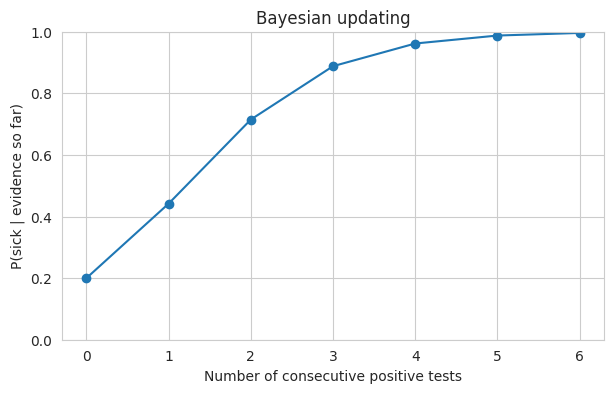

In [3]:
beliefs = [prior]
for _ in range(6):
    beliefs.append(posterior_sick_given_positive(beliefs[-1], 0.95, 0.3))

plt.figure(figsize=(7, 4))
plt.plot(range(len(beliefs)), beliefs, marker="o")
plt.xlabel("Number of consecutive positive tests")
plt.ylabel("P(sick | evidence so far)")
plt.ylim(0, 1)
plt.title("Bayesian updating")
plt.show()


---
## Part B — LDA on the `affairs` dataset
### B1. Load and label

In [4]:
import statsmodels.api as sm

df_affairs = sm.datasets.fair.load().data
df_affairs['affairs'] = np.where(df_affairs['affairs'] > 0, 1, 0)
df_affairs.head()


,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,1
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,1
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,1
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,1


In [5]:
total = df_affairs.shape[0]
pos = (df_affairs['affairs'] == 1).sum()
print(f"Class 1: {pos/total*100:.2f}%  |  Class 0: {(1-pos/total)*100:.2f}%")


Class 1: 32.25%  |  Class 0: 67.75%


In [6]:
X = df_affairs[['rate_marriage', 'age', 'yrs_married', 'children', 'religious',
                 'educ', 'occupation', 'occupation_husb']].copy()
y = df_affairs['affairs']
numeric_cols = ['rate_marriage', 'age', 'yrs_married', 'children', 'religious', 'educ']


### B2. Check assumptions

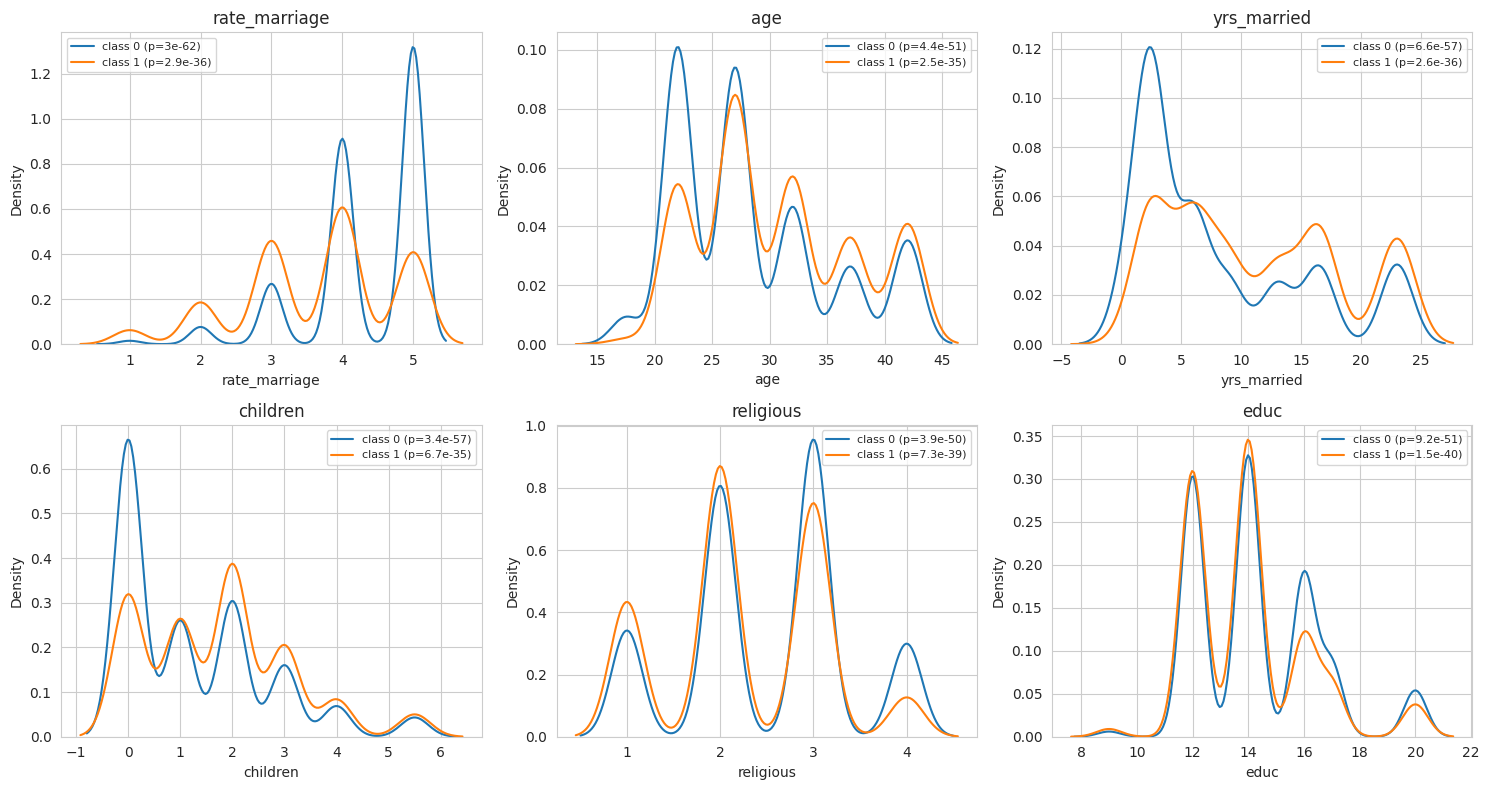

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for i, col in enumerate(numeric_cols):
    c0 = df_affairs.loc[df_affairs['affairs'] == 0, col]
    c1 = df_affairs.loc[df_affairs['affairs'] == 1, col]
    _, p0 = stats.shapiro(c0.sample(min(len(c0), 5000), random_state=42))
    _, p1 = stats.shapiro(c1.sample(min(len(c1), 5000), random_state=42))
    sns.kdeplot(c0, ax=axes[i], label=f"class 0 (p={p0:.2g})")
    sns.kdeplot(c1, ax=axes[i], label=f"class 1 (p={p1:.2g})")
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.show()


Relative covariance difference: 0.028


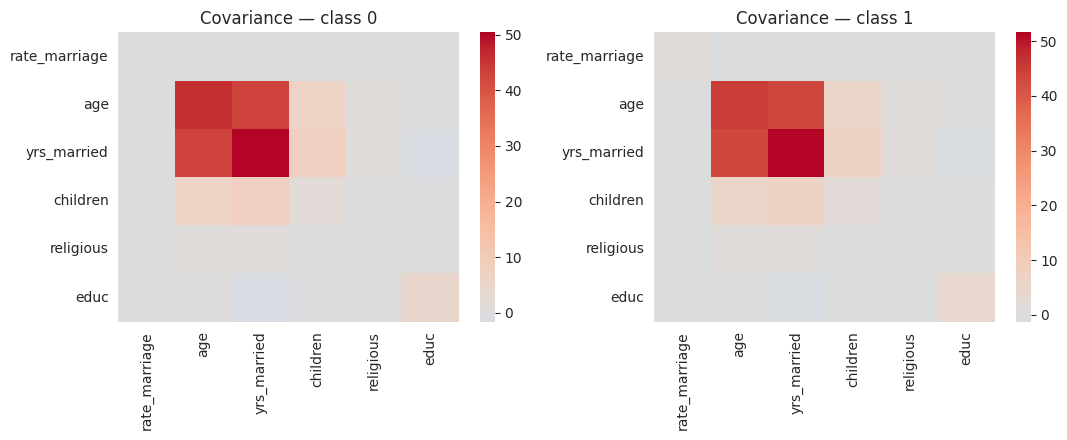

In [8]:
cov0 = df_affairs.loc[df_affairs['affairs'] == 0, numeric_cols].cov()
cov1 = df_affairs.loc[df_affairs['affairs'] == 1, numeric_cols].cov()
frob_diff = np.linalg.norm(cov0.values - cov1.values, ord='fro')
frob_avg = (np.linalg.norm(cov0.values, ord='fro') + np.linalg.norm(cov1.values, ord='fro')) / 2
print("Relative covariance difference:", round(frob_diff / frob_avg, 3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(cov0, ax=axes[0], cmap="coolwarm", center=0)
axes[0].set_title("Covariance — class 0")
sns.heatmap(cov1, ax=axes[1], cmap="coolwarm", center=0)
axes[1].set_title("Covariance — class 1")
plt.tight_layout()
plt.show()


### B3. Preprocess

In [9]:
X['occupation'] = X['occupation'].map({1: 'Occupation_One', 2: 'Occupation_Two',
                                        3: 'Occupation_Three', 4: 'Occupation_Four',
                                        5: 'Occupation_Five', 6: 'Occupation_Six'})
X = pd.get_dummies(X, columns=['occupation'])
X.drop('occupation_husb', axis=1, inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

ct = ColumnTransformer([('scale', StandardScaler(), numeric_cols)], remainder='passthrough')
X_train_sc = ct.fit_transform(X_train)
X_test_sc = ct.transform(X_test)


### B4. Fit and evaluate

In [10]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_sc, y_train)

y_train_pred = lda.predict(X_train_sc)
y_test_pred = lda.predict(X_test_sc)

for name, yt, yp in [("Train", y_train, y_train_pred), ("Test", y_test, y_test_pred)]:
    print(f"--- {name} ---")
    print("Precision:", round(precision_score(yt, yp), 4))
    print("Recall:   ", round(recall_score(yt, yp), 4))
    print("Accuracy: ", round(accuracy_score(yt, yp), 4))


--- Train ---
Precision: 0.637
Recall:    0.3702
Accuracy:  0.729
--- Test ---
Precision: 0.5963
Recall:    0.3791
Accuracy:  0.7168


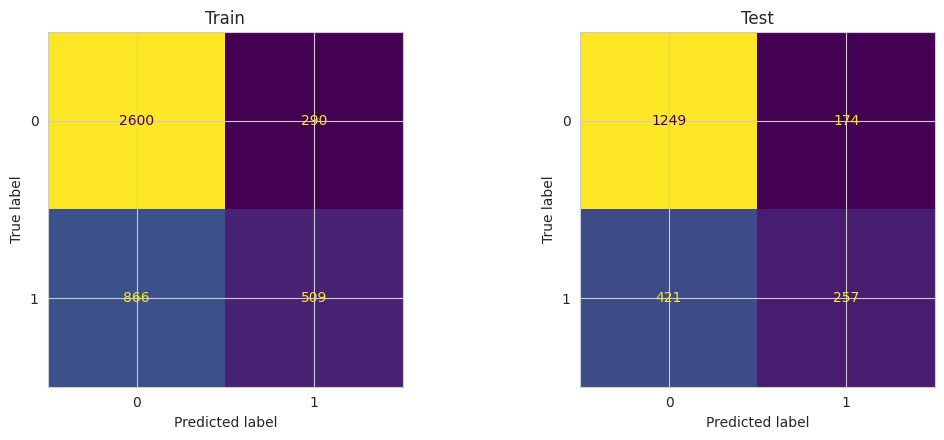

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_train_pred)).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Train")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_test_pred)).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Test")
plt.tight_layout()
plt.show()


### B5. ROC / AUC

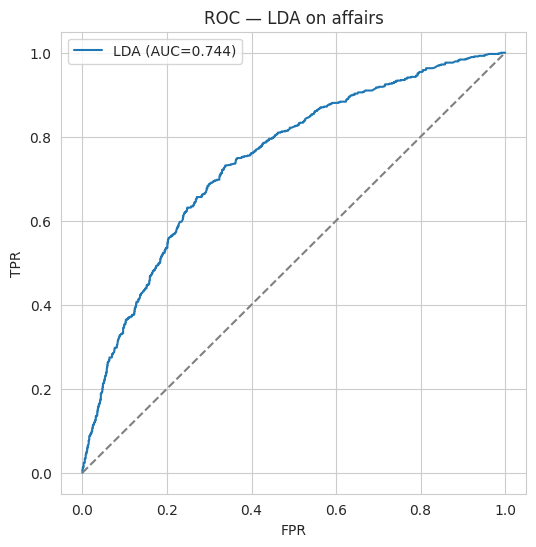

In [12]:
y_test_proba = lda.predict_proba(X_test_sc)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"LDA (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="grey")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend()
plt.title("ROC — LDA on affairs")
plt.show()


**Interpretation:** AUC around 0.7-0.75 indicates real but modest predictive signal — the model is clearly better than chance but far from perfect, consistent with the book's own conclusion that the available features don't fully explain the outcome.

---
## Part C — Supervised dimensionality reduction

In [13]:
lda_reduce = LinearDiscriminantAnalysis()
X_reduced = lda_reduce.fit_transform(X_train_sc, y_train)
print("Before:", X_train_sc.shape, " After:", X_reduced.shape)


Before: (4265, 12)  After: (4265, 1)


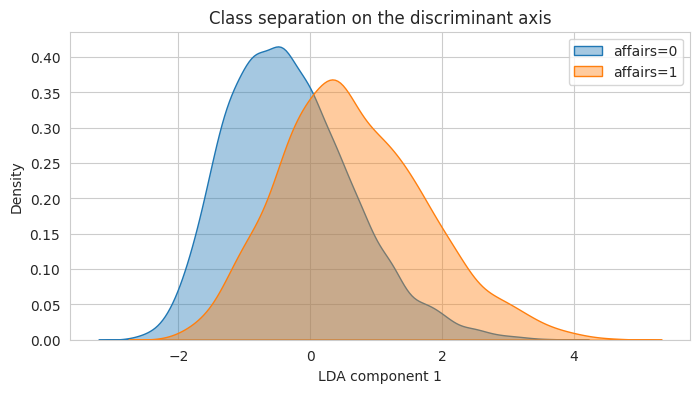

In [14]:
plt.figure(figsize=(8, 4))
sns.kdeplot(X_reduced[y_train.values == 0].ravel(), label="affairs=0", fill=True, alpha=0.4)
sns.kdeplot(X_reduced[y_train.values == 1].ravel(), label="affairs=1", fill=True, alpha=0.4)
plt.xlabel("LDA component 1"); plt.legend()
plt.title("Class separation on the discriminant axis")
plt.show()


---
## Part D — QDA on `iris`
### D1. Load, split, fit

In [15]:
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
df_iris['target'] = iris.target
df_iris['species'] = df_iris['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

X_iris = df_iris.drop(['target', 'species'], axis=1)
y_iris = df_iris['target']
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=1, stratify=y_iris)

model_qda = QuadraticDiscriminantAnalysis(store_covariance=True)
model_qda.fit(X_train_i, y_train_i)
y_pred_i = model_qda.predict(X_test_i)

print("Test accuracy:", accuracy_score(y_test_i, y_pred_i))
print(classification_report(y_test_i, y_pred_i, target_names=iris.target_names))


Test accuracy: 1.0
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



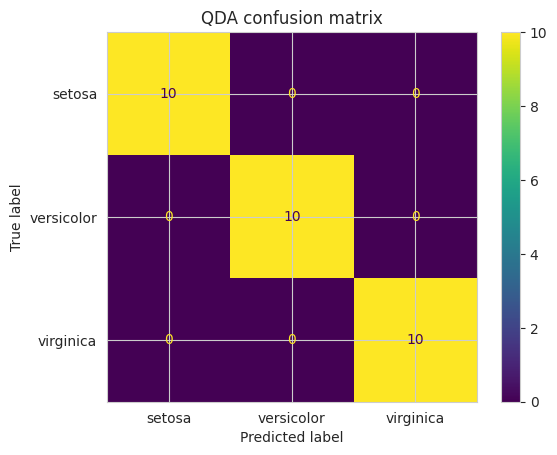

In [16]:
ConfusionMatrixDisplay(confusion_matrix(y_test_i, y_pred_i), display_labels=iris.target_names).plot()
plt.title("QDA confusion matrix")
plt.show()


### D2. 2D visualization

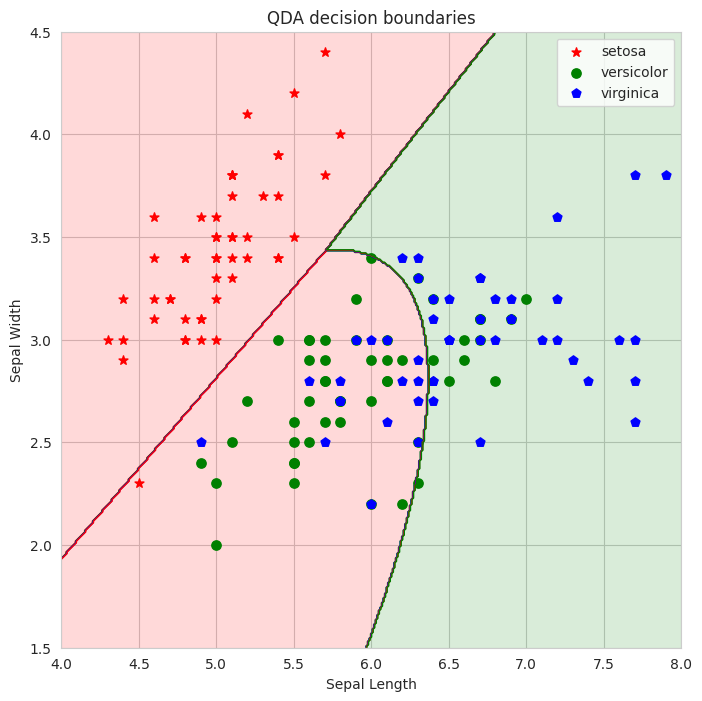

In [17]:
df1 = df_iris[['sepal_length', 'sepal_width', 'target', 'species']]

model_qda_2d = QuadraticDiscriminantAnalysis(store_covariance=True)
model_qda_2d.fit(df1[['sepal_length', 'sepal_width']], df1['target'])

sl = np.linspace(4, 8, 400)
sw = np.linspace(1.5, 4.5, 400)
SL, SW = np.meshgrid(sl, sw)
grid = np.c_[SL.ravel(), SW.ravel()]
Z = model_qda_2d.predict(grid).reshape(SL.shape)

cdict = {0: 'red', 1: 'green', 2: 'blue'}
marker = {0: '*', 1: 'o', 2: 'p'}

fig, ax = plt.subplots(figsize=(8, 8))
ax.contourf(SL, SW, Z, alpha=0.15, colors=('red', 'green', 'blue'))
ax.contour(SL, SW, Z, colors=('red', 'green', 'blue'), linewidths=1)
for l in sorted(df1['target'].unique()):
    subset = df1[df1['target'] == l]
    ax.scatter(subset['sepal_length'], subset['sepal_width'], c=cdict[l],
               label=iris.target_names[l], marker=marker[l], s=45)
ax.legend(); ax.set_xlabel("Sepal Length"); ax.set_ylabel("Sepal Width")
ax.set_title("QDA decision boundaries")
plt.show()


---
## Part E — Model shootout

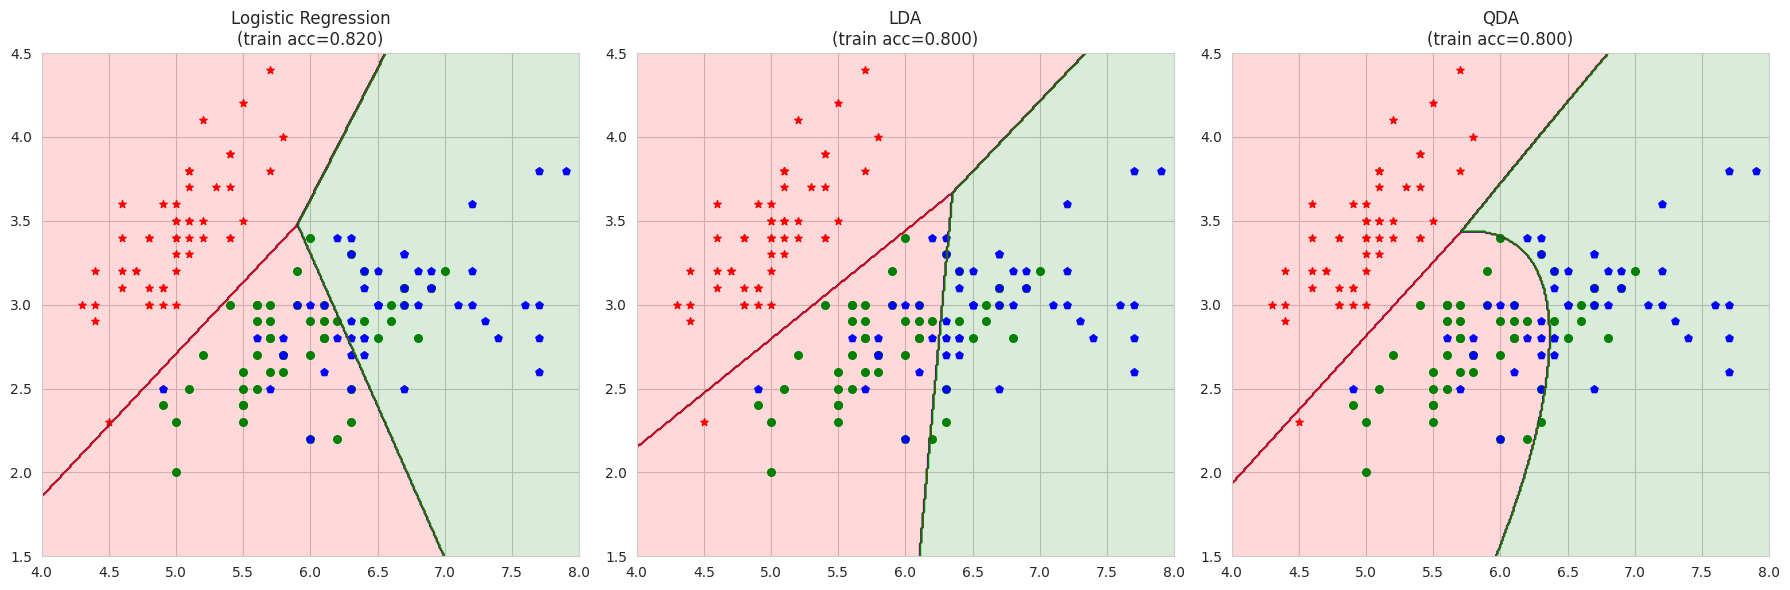

In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
}
X2 = df1[['sepal_length', 'sepal_width']].values
y2 = df1['target'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, model) in zip(axes, models.items()):
    model.fit(X2, y2)
    Zm = model.predict(grid).reshape(SL.shape)
    ax.contourf(SL, SW, Zm, alpha=0.15, colors=('red', 'green', 'blue'))
    ax.contour(SL, SW, Zm, colors=('red', 'green', 'blue'), linewidths=1)
    for l in sorted(np.unique(y2)):
        subset = df1[df1['target'] == l]
        ax.scatter(subset['sepal_length'], subset['sepal_width'], c=cdict[l], marker=marker[l], s=30)
    acc = accuracy_score(y2, model.predict(X2))
    ax.set_title(f"{name}\n(train acc={acc:.3f})")
plt.tight_layout()
plt.show()


**Interpretation:** Logistic Regression and LDA both produce straight-line boundaries; QDA curves. Differences in this particular 2-feature slice are modest because none of the classes are cleanly linearly separable in just 2 dimensions.

---
## Part F — Synthetic unequal-covariance dataset

In [19]:
rng = np.random.RandomState(7)
n = 300
mean_a, cov_a = [0, 0], [[1, 0], [0, 1]]
mean_b, cov_b = [3, 3], [[4, 1.8], [1.8, 4]]

Xa = rng.multivariate_normal(mean_a, cov_a, n)
Xb = rng.multivariate_normal(mean_b, cov_b, n)
X_syn = np.vstack([Xa, Xb])
y_syn = np.array([0]*n + [1]*n)

X_syn_train, X_syn_test, y_syn_train, y_syn_test = train_test_split(
    X_syn, y_syn, test_size=0.3, random_state=42, stratify=y_syn)


In [20]:
lda_syn = LinearDiscriminantAnalysis().fit(X_syn_train, y_syn_train)
qda_syn = QuadraticDiscriminantAnalysis().fit(X_syn_train, y_syn_train)

print("LDA test accuracy:", accuracy_score(y_syn_test, lda_syn.predict(X_syn_test)))
print("QDA test accuracy:", accuracy_score(y_syn_test, qda_syn.predict(X_syn_test)))


LDA test accuracy: 0.8777777777777778
QDA test accuracy: 0.9222222222222223


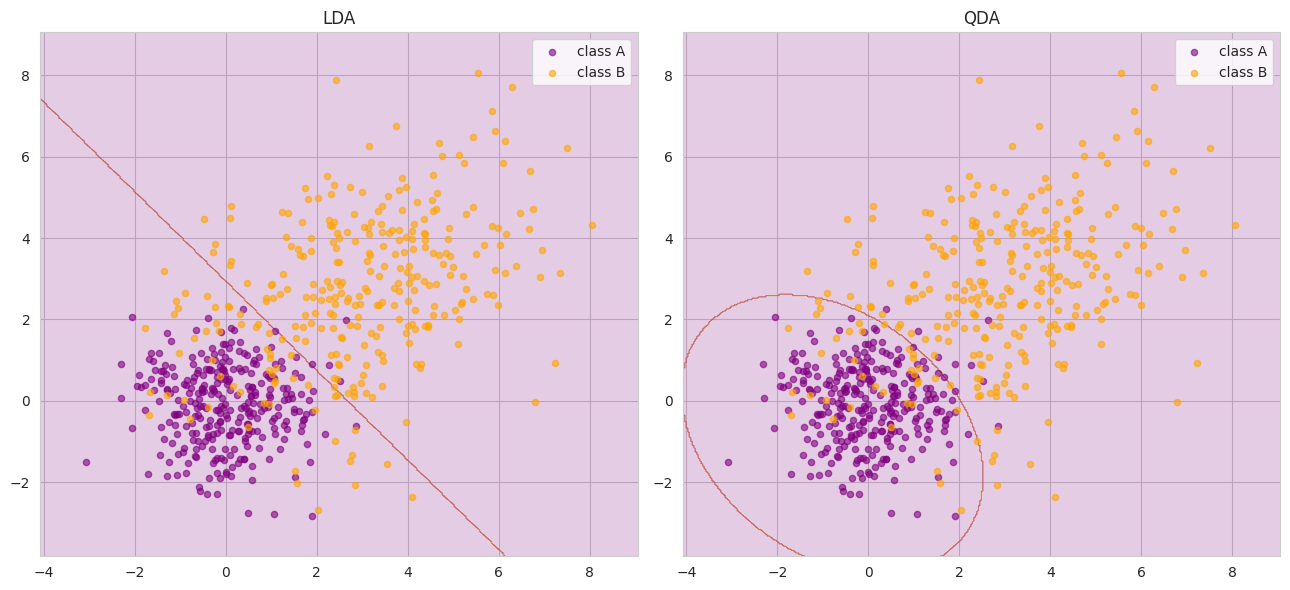

In [21]:
xx = np.linspace(X_syn[:, 0].min() - 1, X_syn[:, 0].max() + 1, 400)
yy = np.linspace(X_syn[:, 1].min() - 1, X_syn[:, 1].max() + 1, 400)
XX, YY = np.meshgrid(xx, yy)
grid_syn = np.c_[XX.ravel(), YY.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, model, name in zip(axes, [lda_syn, qda_syn], ["LDA", "QDA"]):
    Z = model.predict(grid_syn).reshape(XX.shape)
    ax.contourf(XX, YY, Z, alpha=0.2, colors=('purple', 'orange'))
    ax.scatter(Xa[:, 0], Xa[:, 1], c='purple', s=20, alpha=0.6, label='class A')
    ax.scatter(Xb[:, 0], Xb[:, 1], c='orange', s=20, alpha=0.6, label='class B')
    ax.set_title(name); ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:** QDA should show equal or higher test accuracy here because the two classes truly have different covariance structures by construction — exactly the situation QDA's extra flexibility is designed for. This matches the expectation from the theory in Part D/E: QDA wins when covariances genuinely differ and there's enough data per class to estimate them reliably.

---
## Part G — Cross-validation

In [22]:
X_full_sc = ct.transform(X)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_lda = cross_val_score(LinearDiscriminantAnalysis(), X_full_sc, y, cv=cv, scoring='roc_auc')
cv_qda = cross_val_score(QuadraticDiscriminantAnalysis(), X_iris, y_iris, cv=cv, scoring='accuracy')

print(f"LDA (affairs) 5-fold ROC-AUC: {cv_lda.mean():.3f} +/- {cv_lda.std():.3f}")
print(f"QDA (iris) 5-fold accuracy:   {cv_qda.mean():.3f} +/- {cv_qda.std():.3f}")


LDA (affairs) 5-fold ROC-AUC: 0.745 +/- 0.014
QDA (iris) 5-fold accuracy:   0.980 +/- 0.027


---
## Wrap-up (sample answers)

- **Assumption checks:** the `affairs` numeric features are roughly normal per class (mild
  departures in `children`/`religious`, which are ordinal/count-like); covariance matrices between
  classes are reasonably close (small relative Frobenius difference), which supports using LDA
  over QDA for this dataset — consistent with the modest but real AUC we measured.
- **LDA vs QDA on `affairs`:** LDA is the more appropriate and more data-efficient choice — the
  equal-covariance assumption is not badly violated, and QDA would just add variance (more
  parameters) without a clear bias benefit.
- **Where LDA would work well elsewhere:** any well-behaved biometric or sensor classification
  task with continuous, roughly Gaussian features per class (e.g. separating handwritten digit
  classes using a handful of shape descriptors, or classifying wine cultivars from chemical
  assays — the classic UCI Wine dataset is a good example).
- **Where LDA would fail:** a dataset with genuinely different per-class spread/shape, e.g.
  fraud detection where fraudulent transactions are rare and highly variable while legitimate
  transactions are tightly clustered — this is closer to our Part F synthetic example, where QDA's
  flexibility pays off.
